# Historical performance of 13F funds — synthetic disclosed books vs the S&P

**Object**: for each filer and quarter (2013Q3–2026Q1), the prior disclosed book is **frozen** and its value-weighted return is computed from daily prices, minus the S&P (SPY total return) → quarterly excess. Per fund: annualized excess, tracking error, information ratio (×√4).

**Source**: `factors/fund_performance/run_perf.py` → `results/fund_performance.csv` (2,114 funds with ≥12 quarters; 938 with ≥20 quarters and median AUM ≥$250M).

**Two standing caveats** (apply to every table in this notebook):
1. This is the **disclosed LONG book** — no shorts, cash, derivatives, leverage or intra-quarter trading. It is not the fund's NAV; it is the leg the 13F can see.
2. The price panel (Yahoo) **lacks delisted names** → survivorship inflates everyone somewhat. Reality is *worse* than these tables.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# project chart standard (senior quant): cumulative returns ALWAYS in log;
# subtle grid; no top/right spines; quantile bands over spaghetti
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "axes.grid": True,
    "grid.alpha": 0.25, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 10,
    "axes.titlesize": 11, "legend.frameon": False})

df = pd.read_csv("../factors/fund_performance/results/fund_performance.csv")
big = df[(df["n_q"] >= 20) & (df["med_aum"] >= 250e6)].copy()
print(f"{len(df)} funds with >=12 quarters | {len(big)} with >=20 quarters and >=$250M")

C:\Users\lsilva\AppData\Local\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\lsilva\AppData\Local\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


2114 funds with >=12 quarters | 938 with >=20 quarters and >=$250M


In [2]:
# distribution — the three headline numbers
q = big[["ann_excess", "ir"]].quantile([0.05, 0.25, 0.5, 0.75, 0.95]).T
q.columns = ["p5", "p25", "median", "p75", "p95"]
display(q.round(3))
print(f"IR > 0:   {(big['ir'] > 0).mean():.0%} of funds")
print(f"IR > 0.5: {(big['ir'] > 0.5).mean():.0%}")
print(f"IR > 1.0: {(big['ir'] > 1.0).mean():.0%}")

,p5,p25,median,p75,p95
ann_excess,-0.093,-0.066,-0.050,-0.033,0.009
ir,-1.170,-0.842,-0.687,-0.435,0.063


IR > 0:   7% of funds
IR > 0.5: 1%
IR > 1.0: 0%


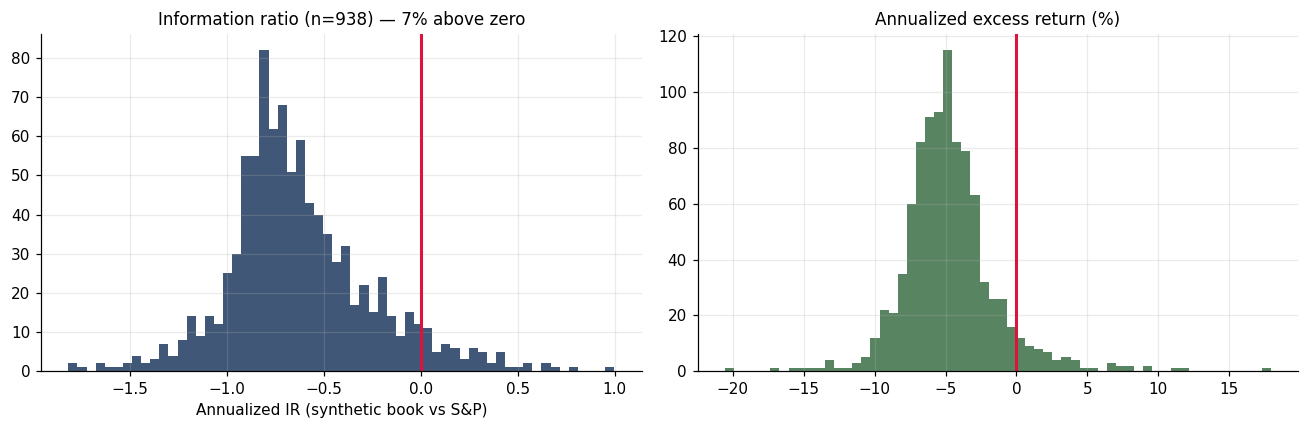

In [3]:
# the deck histogram: IR of institutional books, line at zero
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(big["ir"], bins=60, color="#1e3a5f", alpha=0.85)
ax[0].axvline(0, color="crimson", lw=2)
ax[0].set_title(f"Information ratio (n={len(big)}) — {(big['ir']>0).mean():.0%} above zero")
ax[0].set_xlabel("Annualized IR (synthetic book vs S&P)")
ax[1].hist(big["ann_excess"] * 100, bins=60, color="#3c6e47", alpha=0.85)
ax[1].axvline(0, color="crimson", lw=2)
ax[1].set_title("Annualized excess return (%)")
plt.tight_layout()
plt.savefig("funds_ir_histogram.png", dpi=150)
plt.show()

In [4]:
# top / bottom 20 by IR
cols = ["cik", "name", "n_q", "ann_excess", "te", "ir", "med_aum"]
display(big.nlargest(20, "ir")[cols].round(3))
display(big.nsmallest(20, "ir")[cols].round(3))

,cik,name,n_q,ann_excess,te,ir,med_aum
1283,1767750,NaN,22,0.117,0.117,0.998,2.995340e+08
1683,1753384,NaN,21,0.110,0.143,0.771,3.671650e+08
954,1714267,NaN,33,0.041,0.060,0.678,2.916790e+08
1430,1633799,NaN,23,0.073,0.111,0.660,3.282740e+08
1013,1301050,NaN,30,0.072,0.114,0.630,5.074166e+08
1420,1550660,NaN,24,0.082,0.150,0.545,6.994930e+08
126,1503174,NaN,48,0.094,0.178,0.530,4.503222e+09
1469,1799544,NaN,24,0.065,0.128,0.503,3.246800e+08
1435,1690295,NaN,25,0.179,0.383,0.467,4.738670e+08
1473,1801547,NaN,25,0.036,0.086,0.417,7.797303e+08


,cik,name,n_q,ann_excess,te,ir,med_aum
1260,1443689,NaN,21,-0.131,0.072,-1.816,2.760744e+09
668,937567,NaN,26,-0.112,0.062,-1.794,7.958814e+09
1270,1642575,NaN,25,-0.093,0.054,-1.733,1.445672e+10
1604,1631562,NaN,20,-0.091,0.055,-1.652,5.588282e+09
235,937522,NaN,22,-0.101,0.061,-1.648,9.539887e+08
552,1398318,NaN,28,-0.065,0.040,-1.617,1.829955e+10
161,1061768,NaN,21,-0.102,0.065,-1.557,6.995669e+09
606,923469,NaN,29,-0.094,0.062,-1.511,5.819232e+08
1571,1022314,NaN,21,-0.082,0.055,-1.500,7.307248e+08
1737,1846311,NaN,20,-0.091,0.062,-1.472,7.434715e+08


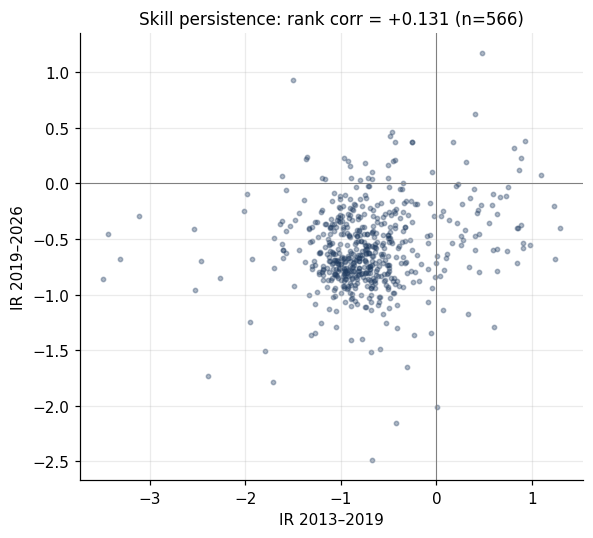

In [5]:
# skill persistence: IR 2013-19 vs 2019-26 — the root number behind smart money
both = df.dropna(subset=["ir_1st", "ir_2nd"])
pers = both["ir_1st"].rank().corr(both["ir_2nd"].rank())
plt.figure(figsize=(5.5, 5))
plt.scatter(both["ir_1st"], both["ir_2nd"], s=8, alpha=0.35, color="#1e3a5f")
plt.axhline(0, color="grey", lw=0.7); plt.axvline(0, color="grey", lw=0.7)
plt.xlabel("IR 2013–2019"); plt.ylabel("IR 2019–2026")
plt.title(f"Skill persistence: rank corr = {pers:+.3f} (n={len(both)})")
plt.tight_layout(); plt.savefig("funds_persistence.png", dpi=150); plt.show()

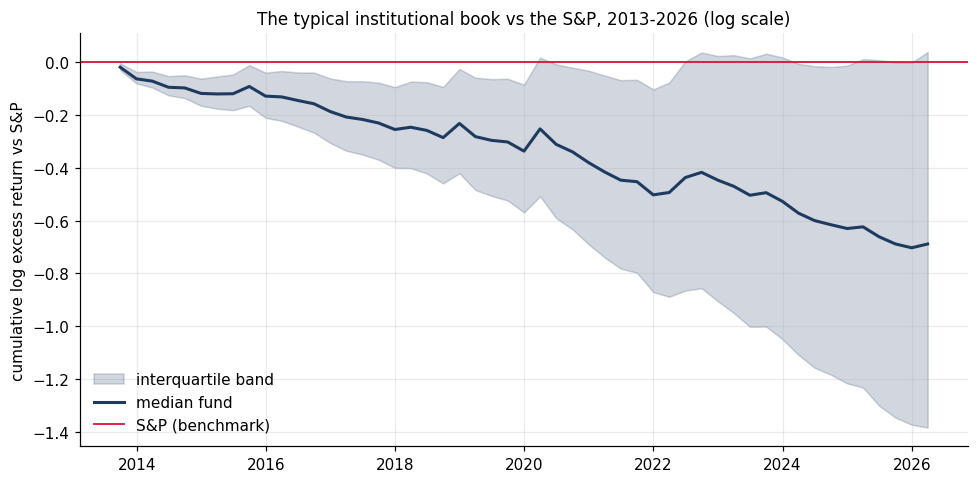

median cumulative log excess at the end: -0.69 (= -50% in level)


In [6]:
# THE REPORT CHART: cumulative LOG excess of the median fund, IQR band.
# Log is the desk standard: compounding becomes a line, drawdowns readable.
panel = pd.read_csv(
    "../factors/fund_performance/results/quarterly_excess.csv.gz",
    index_col=0, parse_dates=True)
logx = np.log1p(panel)                     # log excess per fund/quarter
med = logx.median(axis=1).cumsum()
p25 = logx.quantile(0.25, axis=1).cumsum()
p75 = logx.quantile(0.75, axis=1).cumsum()
plt.figure(figsize=(9, 4.5))
plt.fill_between(med.index, p25, p75, alpha=0.20, color="#1e3a5f",
                 label="interquartile band")
plt.plot(med.index, med, color="#1e3a5f", lw=2, label="median fund")
plt.axhline(0, color="crimson", lw=1.2, label="S&P (benchmark)")
plt.ylabel("cumulative log excess return vs S&P")
plt.title("The typical institutional book vs the S&P, 2013-2026 (log scale)")
plt.legend(loc="lower left")
plt.tight_layout(); plt.savefig("funds_cum_log_excess.png"); plt.show()
print(f"median cumulative log excess at the end: {med.iloc[-1]:+.2f} "
      f"(= {np.expm1(med.iloc[-1]):+.0%} in level)")

In [7]:
# Performance by fund GROUPS (quintiles of full-period characteristics).
# CAVEATS, stated before reading: (a) grouping by full-period traits uses
# information not available in real time -> DESCRIPTIVE, not a strategy;
# (b) the AUM table has survivorship-style LEAKAGE: funds are big partly
# BECAUSE they performed - read it as an association, never causation.

def group_table(metric, label, q=5):
    sub = big.dropna(subset=[metric]).copy()
    sub["bucket"] = pd.qcut(sub[metric].rank(method="first"), q,
                            labels=[f"Q{i+1}" for i in range(q)])
    t = sub.groupby("bucket", observed=True).agg(
        n=("ir", "size"),
        metric_median=(metric, "median"),
        ann_excess_med=("ann_excess", "median"),
        ir_median=("ir", "median"),
        ir_mean=("ir", "mean"),
        pct_ir_pos=("ir", lambda s: (s > 0).mean()))
    t["ann_excess_med"] = (t["ann_excess_med"] * 100).round(1)
    t["pct_ir_pos"] = (t["pct_ir_pos"] * 100).round(0)
    print(f"\n=== {label} (Q1 = lowest) ===")
    display(t.round(3))
    return t

t1 = group_table("act_share", "1) ACTIVE SHARE quintiles (full-period mean)")
t2 = group_table("med_aum", "2) EQUITY BOOK SIZE quintiles (median AUM) - LEAKAGE caveat")
t3 = group_table("turnover", "3) TURNOVER quintiles (mean 0.5*sum|dw| per quarter)")
t4 = group_table("n_pos", "4) NUMBER OF POSITIONS quintiles (diversification)")


=== 1) ACTIVE SHARE quintiles (full-period mean) (Q1 = lowest) ===


,n,metric_median,ann_excess_med,ir_median,ir_mean,pct_ir_pos
bucket,,,,,,
Q1,188,0.919,-5.1,-0.802,-0.788,1.0
Q2,187,0.950,-5.4,-0.756,-0.711,4.0
Q3,188,0.970,-5.0,-0.654,-0.569,11.0
Q4,187,0.986,-5.1,-0.617,-0.564,10.0
Q5,188,1.000,-4.3,-0.516,-0.487,8.0



=== 2) EQUITY BOOK SIZE quintiles (median AUM) - LEAKAGE caveat (Q1 = lowest) ===


,n,metric_median,ann_excess_med,ir_median,ir_mean,pct_ir_pos
bucket,,,,,,
Q1,188,3.167247e+08,-4.9,-0.637,-0.554,11.0
Q2,187,5.339840e+08,-5.3,-0.703,-0.616,9.0
Q3,188,9.316860e+08,-5.3,-0.725,-0.639,6.0
Q4,187,2.366117e+09,-4.8,-0.624,-0.599,6.0
Q5,188,1.119923e+10,-4.6,-0.721,-0.711,2.0



=== 3) TURNOVER quintiles (mean 0.5*sum|dw| per quarter) (Q1 = lowest) ===


,n,metric_median,ann_excess_med,ir_median,ir_mean,pct_ir_pos
bucket,,,,,,
Q1,188,0.058,-5.5,-0.755,-0.722,1.0
Q2,187,0.076,-5.3,-0.754,-0.703,4.0
Q3,188,0.102,-5.0,-0.711,-0.658,5.0
Q4,187,0.154,-4.4,-0.590,-0.531,12.0
Q5,188,0.334,-4.5,-0.511,-0.505,12.0



=== 4) NUMBER OF POSITIONS quintiles (diversification) (Q1 = lowest) ===


,n,metric_median,ann_excess_med,ir_median,ir_mean,pct_ir_pos
bucket,,,,,,
Q1,188,26.897,-3.2,-0.326,-0.315,24.0
Q2,187,67.917,-4.9,-0.610,-0.589,7.0
Q3,188,125.247,-5.4,-0.719,-0.684,2.0
Q4,187,241.171,-5.8,-0.754,-0.735,1.0
Q5,188,793.224,-4.9,-0.794,-0.797,1.0


## Why beating the S&P is so hard — the paragraph (memo/report)

> The median of the 938 large institutional books underperformed the S&P by ~5% per year for 13 years, **before fees** — and this is not primarily incompetence; it is composition arithmetic. The cap-weighted S&P is a portfolio that self-concentrates in its winners: over 2013–2026 a handful of mega caps generated most of the index's return while the *median* stock fell far behind it (Bessembinder's 2018 general result: aggregate market returns come from a tiny minority of stocks, and most stocks underperform even T-bills). Any portfolio more diversified than cap-weight — and **every** 13F book is, by mandate, liquidity or prudence — implicitly carries an equal-weight/small tilt that, in this regime, is a structural tax of several points a year: diversifying mechanically underweights exactly the few names that drive the index. Beating the S&P in this regime required extreme concentration in the mega winners (the opposite of what diversification and risk management allow) or shorts/leverage the 13F does not show. Two consequences for the project: (1) the naive long-only-vs-S&P design was doomed by this arithmetic regardless of signal quality; (2) following managers means following books structurally losing to this benchmark — the alpha extractable from 13F was never in *imitating* books, but in the **flows and constraints** between them (fresh conviction, forced selling), which is exactly where the falsification funnel found it.

## Numbers for the memo (5p) and the final report (~60p)

| number | value | use |
|---|---|---|
| median annualized excess | **−5.0%/yr** (p5 −9.3% / p95 +0.9%) | "the universe" section |
| median IR | **−0.69** | same |
| funds with IR>0 / >0.5 / >1.0 | **7% / 1% / 0%** | the industry ceiling in disclosed books |
| best IR in the universe | **1.0** ($0.3bn fund, 22 quarters) | yardstick for our own Sharpes |
| **skill persistence (rank corr of IR, 1st vs 2nd half)** | **+0.131** (n=566) | the root number behind all 4 smart-money-weighting deaths; cite with U1–U4, EB, vol-weight, sigmoid |
| survivorship | UPWARD bias in all tables | mandatory caveat |

**Report connections**: (i) motivates the combo's long-short design (excess vs S&P is the wrong yardstick for cross-sectional signals); (ii) explains why the naive 26 long-only strategies never had a structural chance; (iii) closes the smart-money family with our own measurement instead of a literature citation; (iv) motivates the central thesis: 13F informs through FLOW and CONSTRAINT, not imitation.

Charts saved by this notebook: `funds_ir_histogram.png`, `funds_persistence.png`, **`funds_cum_log_excess.png` (the log curve — the report chart)**.

**Project chart standard** (rcParams in cell 2): cumulative returns always in **log**; subtle grid; quantile bands over spaghetti; save at ≥150 dpi.